# Лабораторная работа 5

Тема: **Регуляризация и нормализация в нейросетях (L2, Dropout, BatchNorm)**  
Цель: на одной и той же задаче (MNIST в PyTorch) изучить, как разные приёмы регуляризации влияют на переобучение и качество обобщения, и сформулировать **свои** выводы по результатам экспериментов.

> Этот ноутбук — заготовка под вашу работу, а не готовый отчёт.  
> Если вы попытаетесь автоматически заполнить его текст генеративной моделью, это проявится в стиле, обобщённости формулировок и несоответствии коду/графикам.
> Оценка ставится за:
> - осмысленный код (который вы можете объяснить),
> - честно проведённые эксперименты,
> - ваши собственные формулировки наблюдений и выводов.

## 1. Ваше предварительное представление о регуляризации

Перед тем как трогать PyTorch, сформулируйте для себя:

1. Что вы называете «переобучением» в контексте нейросетей (на своём языке, без академических определений).  
2. Почему, на ваш взгляд, регуляризация и нормализация могут помочь, если уже и так «всё обучается»?  
3. В чём принципиальная разница между:
   - L2‑штрафом на веса (weight decay),
   - Dropout,
   - BatchNorm — если объяснять их одногруппнику за 2–3 минуты.

Напишите ответы в следующей ячейке. Здесь важен ваш голос, а не повторение чужого текста — не бойтесь неровных формулировок, главное, чтобы они были **вашими**.

In [1]:
pre_intro = """1) Я понимаю 'переобучение' как ситуацию, в которой модель начинает подстраивать ответы под обучающую выборку.
Она начинает запоминать по каждому примеру ответы, ошибки, и остальные параметры, поэтому на тестовых данных часто возникают ошибки.
Нужно, чтобы она не запоминала ответы, а понимала их суть.

2)Регуляризация и нормализация могут помочь для, например, новых тестовых данных. Если на 100 примерах обучение прошло отлично, то на дополнительных
    20 примерах могут быть ошибки. Так регуляризация и нормализация помогают не запоминать, а понимать. Будет меньше ошибок, скорость выше.

3) L2 и Dropout не дают НС переобучаться, а BatchNorm нормализует. 
    Разница в способах.
    L2 - добавляет штрафы за большие веса;
    Dropout - отключает часть нейронов, чтобы они не работали в зависимости друг с другом;
    BatchNorm используется для  скорости, стабильности.
"""
print(pre_intro)

1) Я понимаю 'переобучение' как ситуацию, в которой модель начинает подстраивать ответы под обучающую выборку.
Она начинает запоминать по каждому примеру ответы, ошибки, и остальные параметры, поэтому на тестовых данных часто возникают ошибки.
Нужно, чтобы она не запоминала ответы, а понимала их суть.

2)Регуляризация и нормализация могут помочь для, например, новых тестовых данных. Если на 100 примерах обучение прошло отлично, то на дополнительных
    20 примерах могут быть ошибки. Так регуляризация и нормализация помогают не запоминать, а понимать. Будет меньше ошибок, скорость выше.

3) L2 и Dropout не дают НС переобучаться, а BatchNorm нормализует. 
    Разница в способах.
    L2 - добавляет штрафы за большие веса;
    Dropout - отключает часть нейронов, чтобы они не работали в зависимости друг с другом;
    BatchNorm используется для  скорости, стабильности.



## 2. Импорт и настройка среды

Сделайте стандартную подготовку:
- импортируйте PyTorch, torchvision и необходимые утилиты;
- зафиксируйте **один** seed (свой, не «магический» 42), чтобы эксперименты можно было воспроизвести;
- определите, есть ли CUDA, но пишите код так, чтобы и на CPU всё работало.


In [2]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# ВАШ SEED (запишите его потом в отчёте)
MY_SEED = 22
torch.manual_seed(MY_SEED)
np.random.seed(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)
print("MY_SEED =", MY_SEED)

Устройство: cpu
MY_SEED = 22


## 3. Данные MNIST и базовая предобработка

Вы уже работали с MNIST в ЛР4, так что здесь не должно быть сюрпризов.  
Задача на этом шаге:
- загрузить train/test;
- применить `ToTensor` и нормализацию (можно стандартную для MNIST);
- выбрать размер батча так, чтобы обучение шло достаточно быстро, но не превращалось в «шум».  

Важно: число `batch_size`, нормализацию и все прочие решения потом нужно будет **объяснить** в отчёте, а не «так было в шаблоне».

In [3]:
batch_size = 128 #TODO: Попробуйте несколько значений. Запишите, как меняется время эпохи и шумность loss-кривой в зависимости от размера батча

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("train size =", len(train_dataset))
print("test size  =", len(test_dataset))
print("batch_size =", batch_size)

train size = 60000
test size  = 10000
batch_size = 128


Быстро посмотрим на несколько картинок, чтобы убедиться, что всё загружается и отображается как ожидается.


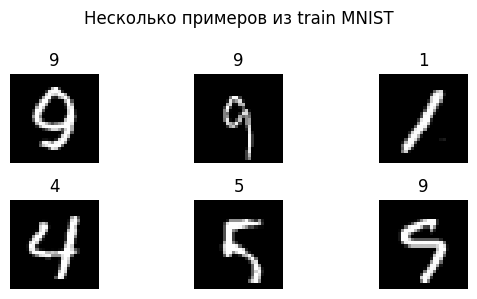

In [4]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(6, 3))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i].squeeze().numpy(), cmap="gray")
    plt.title(f"{labels[i].item()}")
    plt.axis("off")
plt.suptitle("Несколько примеров из train MNIST")
plt.tight_layout()
plt.show()

### Ваши короткие наблюдения по данным

Ответьте здесь буквально в 3–5 предложениях:
- насколько «чистыми» и различимыми кажутся цифры;
- есть ли такие изображения, которые уже сейчас вы бы сами классифицировали с сомнением.

Не пытайтесь «угадывать правильный ответ» — это просто ваши наблюдения.

In [5]:
data_impression = """Цифры не выглядят достаточно чистыми, некоторые очень нечеткие. 
Очень тяжело отличить друг от друга 1 и 7.
В некоторых случаях 4 и 9. 
"""
print(data_impression)

Цифры не выглядят достаточно чистыми, некоторые очень нечеткие. 
Очень тяжело отличить друг от друга 1 и 7.
В некоторых случаях 4 и 9. 



## 4. Три варианта модели

Мы будем сравнивать три архитектурных варианта на одной и той же задаче:

1. **BaseMLP** — без регуляризации (кроме implicit нормализации входа).  
2. **DropoutMLP** — тот же каркас, но с Dropout в скрытых слоях.  
3. **BatchNormMLP** — тот же каркас, но со слоями BatchNorm1d.

L2‑регуляризацию (weight_decay) будем добавлять через оптимизатор к любому из вариантов.

Архитектуру берите не слишком маленькую (чтобы сеть могла переобучиться), но и не чрезмерную.


In [7]:
class BaseMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            # TODO: размеры слоёв (256, 128) выбраны произвольно.
            # Подберите свои значения и обоснуйте в отчёте:
            # достаточно ли этого, чтобы модель вообще могла переобучиться?
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )
    # здесь получится ~110к параметров, достаточно чтобы переобучиться, но и не чрезмерно
    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)


class DropoutMLP(nn.Module):
    def __init__(self, p=0.5):
        super().__init__()
        self.flatten = nn.Flatten()
        # TODO: Dropout стоит ПОСЛЕ активации, это стандартная практика.
        # Попробуйте поставить его ДО активации и опишите, изменилось ли что-то.
        self.net = nn.Sequential(
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(p=p), #TODO: объясните, что физически происходит здесь во время train?

            # во время обучения отключается(обнуляется) часть нейронов с вероятностью p=0.5, остальные тензоры умножены на 1/(1-p)
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(p=p), #TODO: объясните, почему здесь тот же p, а не другой?

            # это необязательно, можно поставить и другой, так удобнее для настройки
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)


class BatchNormMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        # TODO: BatchNorm1d стоит ДО активации — это один из двух стандартных вариантов.
        # Попробуйте переставить его после ReLU. Есть ли разница в сходимости?
        # TODO: объясните в отчёте: что именно нормализует BatchNorm1d(256)?
        # Что такое «батч» в данном контексте, строки или столбцы матрицы?

        # в нашем случае на вход поступает матрица размером (128, 256)
        # 128 - выбранный мною размер батча, поэтому
        # BatchNorm1d(256)  для каждого из 256 признака нормализует значения,
        # а батч - это все строки(128), то есть картинки
        self.net = nn.Sequential(
            nn.Linear(28 * 28, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)

print(BaseMLP())
print(DropoutMLP())
print(BatchNormMLP())

BaseMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (net): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)
DropoutMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (net): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.5, inplace=False)
    (6): Linear(in_features=128, out_features=10, bias=True)
  )
)
BatchNormMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (net): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): Bat

В отчёте вы потом отдельно опишете:
- какие именно размеры слоёв и значения Dropout использовали;
- пробовали ли другие варианты (и чем они закончились).

## 5. Общие функции обучения и оценки

Чтобы не копировать код, напишем универсальные функции:
- `train_one_epoch` — один проход по train;
- `evaluate` — оценка на любом DataLoader.

Если вы хотите добавить дополнительные метрики/логирование — делайте это здесь и прокомментируйте в отчёте.


In [8]:
criterion = nn.CrossEntropyLoss()

def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    running_correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        running_correct += (preds == labels).sum().item()
        total += images.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc


def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            running_correct += (preds == labels).sum().item()
            total += images.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc

print("Функции train_one_epoch и evaluate определены.")

Функции train_one_epoch и evaluate определены.


## 6. Функция запуска эксперимента для одной конфигурации

Чтобы аккуратно сравнивать разные варианты (без регуляризации, с L2, с Dropout, с BatchNorm), удобно иметь одну функцию `run_experiment`, которая:
- создаёт модель;
- настраивает оптимизатор (с нужным `weight_decay` и `lr`);
- обучает модель `num_epochs` эпох;
- возвращает историю `loss/accuracy`.

Важный момент: вы сами выбираете числа эпох, шаг обучения и значения L2/Dropout, но потом должны будете указать их в отчёте и прокомментировать.


In [9]:
def run_experiment(model_class, config_name,
                   weight_decay=0.0, dropout_p=0.5,
                   num_epochs=8, lr=1e-3):
    print("\n=== Конфигурация:", config_name, "===")

    # создаём модель нужного класса
    if model_class is DropoutMLP:
        model = model_class(p=dropout_p).to(device)
    else:
        model = model_class().to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {"train_loss": [], "train_acc": [],
               "test_loss": [], "test_acc": []}

    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        test_loss, test_acc = evaluate(model, test_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        print(f"Эпоха {epoch}/{num_epochs} | "
              f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
              f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}")

    return model, history

print("Функция run_experiment готова.")

Функция run_experiment готова.


## 7. Набор экспериментов (пример)

Рекомендуется провести, как минимум, такие эксперименты:

1. `Base / no_reg` — BaseMLP, `weight_decay=0`.  
2. `Base / L2` — BaseMLP, `weight_decay` (например, `1e-4` или `1e-3`).  
3. `Dropout p=0.5` — DropoutMLP, без L2 для чистоты.  
4. `BatchNorm` — BatchNormMLP, без L2 для начала.  

При желании можно добавить комбинации (BatchNorm + L2, Dropout + L2), но важно успеть осмысленно проанализировать хотя бы базовые варианты.


In [ ]:
# 1. Базовая модель без регуляризации
base_model, base_hist = run_experiment(
    model_class=BaseMLP,
    config_name="Base / no_reg",
    weight_decay=0.0,
    num_epochs=8,
    lr=1e-3
)
# Эпоха 1/8 | test_acc=0.9543
# Эпоха 2/8 | test_acc=0.9621
# Эпоха 3/8 | test_acc=0.9746
# Эпоха 4/8 | test_acc=0.9760
# Эпоха 5/8 | test_acc=0.9782
# Эпоха 6/8 | test_acc=0.9769
# Эпоха 7/8 | test_acc=0.9744
# Эпоха 8/8 | test_acc=0.9782


=== Конфигурация: Base / no_reg ===
Эпоха 1/8 | train_loss=0.3192, train_acc=0.9053, test_loss=0.1492, test_acc=0.9543
Эпоха 2/8 | train_loss=0.1316, train_acc=0.9604, test_loss=0.1249, test_acc=0.9621
Эпоха 3/8 | train_loss=0.0917, train_acc=0.9715, test_loss=0.0857, test_acc=0.9746
Эпоха 4/8 | train_loss=0.0671, train_acc=0.9791, test_loss=0.0808, test_acc=0.9760
Эпоха 5/8 | train_loss=0.0531, train_acc=0.9831, test_loss=0.0720, test_acc=0.9782
Эпоха 6/8 | train_loss=0.0430, train_acc=0.9859, test_loss=0.0770, test_acc=0.9769
Эпоха 7/8 | train_loss=0.0370, train_acc=0.9877, test_loss=0.0833, test_acc=0.9744
Эпоха 8/8 | train_loss=0.0309, train_acc=0.9899, test_loss=0.0772, test_acc=0.9782


In [ ]:
# 2. Базовая модель с L2 (weight decay)
# TODO: weight_decay=1e-4 — почему именно это значение?
# Попробуйте 1e-2 и 1e-6. Запишите test_acc для каждого случая и опишите, где слишком много L2.

# слишком много L2 в случае с 1e-2
# 1e-4 в данном случае дала наилучшее качество на тесте, поэтому из этих вариантов стоит выбрать это
l2_model, l2_hist = run_experiment(
    model_class=BaseMLP,
    config_name="Base / L2 (wd=1e-6)",
    weight_decay=1e-6,
    num_epochs=8,
    lr=1e-3
)


# === Конфигурация: Base / L2 (wd=1e-4) ===
# Эпоха 1/8 | test_acc=0.9555
# Эпоха 2/8 | test_acc=0.9658
# Эпоха 3/8 | test_acc=0.9709
# Эпоха 4/8 | test_acc=0.9737
# Эпоха 5/8 | test_acc=0.9698
# Эпоха 6/8 | test_acc=0.9707
# Эпоха 7/8 | test_acc=0.9724
# Эпоха 8/8 | test_acc=0.9774

# === Конфигурация: Base / L2 (wd=1e-2) ===
# Эпоха 1/8 | test_acc=0.9322
# Эпоха 2/8 | test_acc=0.9547
# Эпоха 3/8 | test_acc=0.9534
# Эпоха 4/8 | test_acc=0.9563
# Эпоха 5/8 | test_acc=0.9535
# Эпоха 6/8 | test_acc=0.9613
# Эпоха 7/8 | test_acc=0.9572
# Эпоха 8/8 | test_acc=0.9635

# === Конфигурация: Base / L2 (wd=1e-6) ===
# Эпоха 1/8 | test_acc=0.9453
# Эпоха 2/8 | test_acc=0.9632
# Эпоха 3/8 | test_acc=0.9696
# Эпоха 4/8 | test_acc=0.9716
# Эпоха 5/8 | test_acc=0.9705
# Эпоха 6/8 | test_acc=0.9739
# Эпоха 7/8 | test_acc=0.9743
# Эпоха 8/8 | test_acc=0.9756


=== Конфигурация: Base / L2 (wd=1e-6) ===
Эпоха 1/8 | train_loss=0.3196, train_acc=0.9070, test_loss=0.1779, test_acc=0.9453
Эпоха 2/8 | train_loss=0.1391, train_acc=0.9579, test_loss=0.1155, test_acc=0.9632
Эпоха 3/8 | train_loss=0.0961, train_acc=0.9705, test_loss=0.0938, test_acc=0.9696
Эпоха 4/8 | train_loss=0.0702, train_acc=0.9786, test_loss=0.0862, test_acc=0.9716
Эпоха 5/8 | train_loss=0.0559, train_acc=0.9825, test_loss=0.0956, test_acc=0.9705
Эпоха 6/8 | train_loss=0.0470, train_acc=0.9848, test_loss=0.0869, test_acc=0.9739
Эпоха 7/8 | train_loss=0.0386, train_acc=0.9874, test_loss=0.0843, test_acc=0.9743
Эпоха 8/8 | train_loss=0.0314, train_acc=0.9902, test_loss=0.0860, test_acc=0.9756


In [ ]:
# 3. Модель с Dropout
# TODO: dropout_p=0.5 — агрессивное значение. Попробуйте p=0.2 и p=0.7.
# При каком p модель обучается слишком медленно, а при каком почти не регуляризует?

# при p=0.2 регуляризация слабая, возникает переобучение
# при p=0.7 слишком медленная, выключается слишком много нейронов 
# при p=0.5 самая оптимальная
drop_model, drop_hist = run_experiment(
    model_class=DropoutMLP,
    config_name="Dropout p=0.7",
    dropout_p=0.7,
    weight_decay=0.0,
    num_epochs=8,
    lr=1e-3
)

# === Конфигурация: Dropout p=0.5 === 
# Эпоха 1/8 | test_acc=0.9504
# Эпоха 2/8 | test_acc=0.9612
# Эпоха 3/8 | test_acc=0.9697
# Эпоха 4/8 | test_acc=0.9709
# Эпоха 5/8 | test_acc=0.9711
# Эпоха 6/8 | test_acc=0.9741
# Эпоха 7/8 | test_acc=0.9746
# Эпоха 8/8 | test_acc=0.9789

# === Конфигурация: Dropout p=0.2 === 
# Эпоха 1/8 | test_acc=0.9601
# Эпоха 2/8 | test_acc=0.9714
# Эпоха 3/8 | test_acc=0.9708
# Эпоха 4/8 | test_acc=0.9788
# Эпоха 5/8 | test_acc=0.9774
# Эпоха 6/8 | test_acc=0.9790
# Эпоха 7/8 | test_acc=0.9806
# Эпоха 8/8 | test_acc=0.9832


# === Конфигурация: Dropout p=0.7 === 
# Эпоха 1/8 | test_acc=0.9322
# Эпоха 2/8 | test_acc=0.9432
# Эпоха 3/8 | test_acc=0.9495
# Эпоха 4/8 | test_acc=0.9570
# Эпоха 5/8 | test_acc=0.9618
# Эпоха 6/8 | test_acc=0.9573
# Эпоха 7/8 | test_acc=0.9630
# Эпоха 8/8 | test_acc=0.9652


=== Конфигурация: Dropout p=0.7 ===
Эпоха 1/8 | train_loss=0.7330, train_acc=0.7692, test_loss=0.2364, test_acc=0.9322
Эпоха 2/8 | train_loss=0.4128, train_acc=0.8831, test_loss=0.1923, test_acc=0.9432
Эпоха 3/8 | train_loss=0.3587, train_acc=0.8993, test_loss=0.1653, test_acc=0.9495
Эпоха 4/8 | train_loss=0.3364, train_acc=0.9077, test_loss=0.1539, test_acc=0.9570
Эпоха 5/8 | train_loss=0.3092, train_acc=0.9144, test_loss=0.1425, test_acc=0.9618
Эпоха 6/8 | train_loss=0.2966, train_acc=0.9180, test_loss=0.1468, test_acc=0.9573
Эпоха 7/8 | train_loss=0.2879, train_acc=0.9197, test_loss=0.1306, test_acc=0.9630
Эпоха 8/8 | train_loss=0.2778, train_acc=0.9231, test_loss=0.1253, test_acc=0.9652


In [ ]:
# 4. Модель с BatchNorm
bn_model, bn_hist = run_experiment(
    model_class=BatchNormMLP,
    config_name="BatchNorm",
    weight_decay=0.0,
    num_epochs=8,
    lr=1e-3
)

# === Конфигурация: BatchNorm ===
# Эпоха 1/8 | test_acc=0.9711
# Эпоха 2/8 | test_acc=0.9772
# Эпоха 3/8 | test_acc=0.9767
# Эпоха 4/8 | test_acc=0.9792
# Эпоха 5/8 | test_acc=0.9787
# Эпоха 6/8 | test_acc=0.9794
# Эпоха 7/8 | test_acc=0.9805
# Эпоха 8/8 | test_acc=0.9800


=== Конфигурация: BatchNorm ===
Эпоха 1/8 | train_loss=0.2250, train_acc=0.9417, test_loss=0.0963, test_acc=0.9711
Эпоха 2/8 | train_loss=0.0782, train_acc=0.9764, test_loss=0.0736, test_acc=0.9772
Эпоха 3/8 | train_loss=0.0511, train_acc=0.9840, test_loss=0.0706, test_acc=0.9767
Эпоха 4/8 | train_loss=0.0368, train_acc=0.9880, test_loss=0.0671, test_acc=0.9792
Эпоха 5/8 | train_loss=0.0278, train_acc=0.9909, test_loss=0.0676, test_acc=0.9787
Эпоха 6/8 | train_loss=0.0234, train_acc=0.9928, test_loss=0.0705, test_acc=0.9794
Эпоха 7/8 | train_loss=0.0212, train_acc=0.9929, test_loss=0.0700, test_acc=0.9805
Эпоха 8/8 | train_loss=0.0165, train_acc=0.9945, test_loss=0.0711, test_acc=0.9800


## 8. Визуальное сравнение кривых

Теперь важно не просто посмотреть на финальные числа, а **сравнить динамику** обучения для разных вариантов: 
как меняются train/test loss и accuracy по эпохам.

Сделаем один общий график для всех конфигураций.


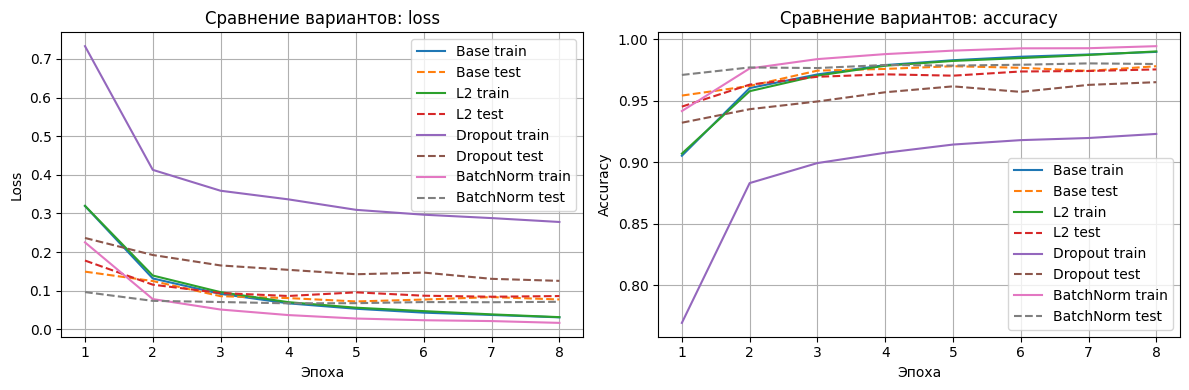

In [18]:
def plot_histories(histories, labels, title_prefix=""):
    plt.figure(figsize=(12, 4))

    # Loss
    plt.subplot(1, 2, 1)
    for hist, label in zip(histories, labels):
        epochs = np.arange(1, len(hist["train_loss"]) + 1)
        plt.plot(epochs, hist["train_loss"], label=f"{label} train")
        plt.plot(epochs, hist["test_loss"], linestyle="--", label=f"{label} test")
    plt.xlabel("Эпоха")
    plt.ylabel("Loss")
    plt.title(title_prefix + "loss")
    plt.grid(True)
    plt.legend()

    # Accuracy
    plt.subplot(1, 2, 2)
    for hist, label in zip(histories, labels):
        epochs = np.arange(1, len(hist["train_acc"]) + 1)
        plt.plot(epochs, hist["train_acc"], label=f"{label} train")
        plt.plot(epochs, hist["test_acc"], linestyle="--", label=f"{label} test")
    plt.xlabel("Эпоха")
    plt.ylabel("Accuracy")
    plt.title(title_prefix + "accuracy")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_histories(
    histories=[base_hist, l2_hist, drop_hist, bn_hist],
    labels=["Base", "L2", "Dropout", "BatchNorm"],
    title_prefix="Сравнение вариантов: "
)

## 9. Ваш разбор результатов

Теперь самая важная (и самая «анти‑генеративная») часть: **живой разбор** того, что вы увидели на графиках и в числах.

Постарайтесь ответить (в свободной форме, без маркированного списка):

- Как вёл себя разрыв между train и test для базовой модели? Было ли заметное переобучение уже к 8‑й эпохе?  
- Что дало добавление L2: стало ли train хуже, а test лучше/стабильнее?  
- Как ведёт себя Dropout: не «ломает» ли он обучение в начале, не делает ли train слишком шумным?  
- Что меняет BatchNorm: меняется ли скорость выхода на насыщение по точности, становятся ли кривые «ровнее»?  
- Если нужно было выбрать **одну** технику регуляризации для этой задачи, что бы вы выбрали и почему (с опорой на ваши конкретные графики и числа)?

Не стесняйтесь упоминать неудачные настройки (слишком большой weight_decay, странный Dropout и т.п.) — это тоже часть обучения.


In [ ]:
analysis_comment = """ЗДЕСЬ НАПИШИТЕ РАЗВЁРНУТЫЙ КОММЕНТАРИЙ К ГРАФИКАМ И ЧИСЛАМ.
Ссылайтесь на конкретные значения (например, test accuracy для Base и L2) и
опишите, как выглядят кривые. Не бойтесь писать «по‑человечески».
Ценность текста в том, чтобы через несколько месяцев вы сами вспомнили ход
экспериментов и свои выводы."""
print(analysis_comment)

## 10. Итоговое резюме по лабораторной работе

В конце сформулируйте короткое резюме (5–8 предложений):

- Какие **конкретные** настройки (архитектура, lr, weight_decay, Dropout‑p, число эпох) вы в итоге считаете для этой задачи «золотой серединой» и почему.  
- Чем ваши ожидания по эффекту регуляризации совпали / не совпали с тем, что вы реально увидели.  
- Как вы теперь объяснили бы одногруппнику, когда есть смысл использовать L2, когда Dropout, а когда BatchNorm — именно на примере **ваших** экспериментов, а не абстрактной теории.


In [ ]:
final_summary = """ЗДЕСЬ НАПИШИТЕ ИТОГОВОЕ РЕЗЮМЕ.
Сделайте акцент на том, что вы унесёте из этой работы дальше: какие настройки и
приёмы будете пробовать в следующих задачах и почему."""
print(final_summary)